# 8. Grover's Algorithm

Grover's algorithm searches an unsorted list of `N = 2^n` items for
one "marked" item in about `sqrt(N)` steps — a quadratic speedup
over the best possible classical search, which needs about `N/2`
steps on average.

Here we search a list of `2^3 = 8` items for a hidden marked item:
`101`.

## Step 1: Import libraries

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import math

simulator = AerSimulator()
n = 3                  # number of qubits -> 2^3 = 8 items to search
marked_state = "101"   # the item we are looking for

## Step 2: Build the oracle

The oracle flips the *phase* (sign) of the marked state, leaving
every other state unchanged. We build it using X gates around a
multi-controlled Z, so it only triggers on `101`.

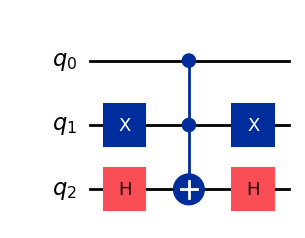

In [2]:
oracle = QuantumCircuit(n, name="Oracle")

# Flip the qubits that should be 0 in the marked state, so the
# multi-controlled Z below only fires on |101>
for i, bit in enumerate(reversed(marked_state)):
    if bit == "0":
        oracle.x(i)

oracle.h(n - 1)
oracle.mcx(list(range(n - 1)), n - 1)   # multi-controlled X = controlled-Z here
oracle.h(n - 1)

for i, bit in enumerate(reversed(marked_state)):
    if bit == "0":
        oracle.x(i)

oracle.draw("mpl")

## Step 3: Build the diffuser

The diffuser reflects the amplitudes about their average, which
boosts the marked state's probability and shrinks the others.

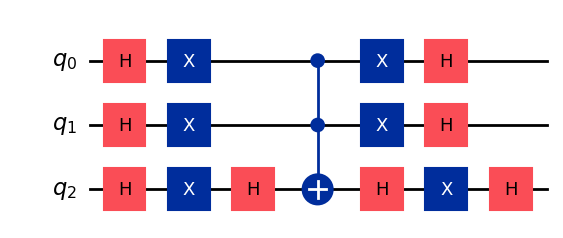

In [3]:
diffuser = QuantumCircuit(n, name="Diffuser")
diffuser.h(range(n))
diffuser.x(range(n))

diffuser.h(n - 1)
diffuser.mcx(list(range(n - 1)), n - 1)
diffuser.h(n - 1)

diffuser.x(range(n))
diffuser.h(range(n))
diffuser.draw("mpl")

## Step 4: Assemble the full Grover circuit

For `N = 8` items, the optimal number of oracle+diffuser rounds is
about `(pi/4) * sqrt(8) ≈ 2`.

Number of Grover iterations to use: 2


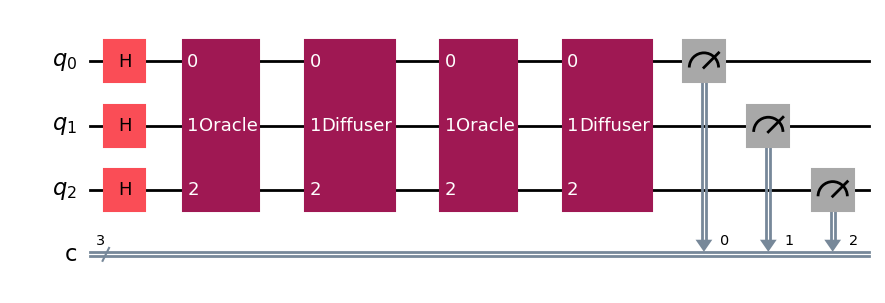

In [4]:
N_items = 2 ** n
iterations = round((math.pi / 4) * math.sqrt(N_items))
print("Number of Grover iterations to use:", iterations)

qc = QuantumCircuit(n, n)

# Start in equal superposition over all 8 possible items
qc.h(range(n))

oracle_gate = oracle.to_gate()
diffuser_gate = diffuser.to_gate()

for _ in range(iterations):
    qc.append(oracle_gate, range(n))
    qc.append(diffuser_gate, range(n))

qc.measure(range(n), range(n))
qc.draw("mpl", fold=120)

## Step 5: Run it on the Aer simulator

Measurement counts: {'110': 10, '001': 18, '100': 17, '111': 20, '011': 22, '010': 20, '000': 19, '101': 1922}


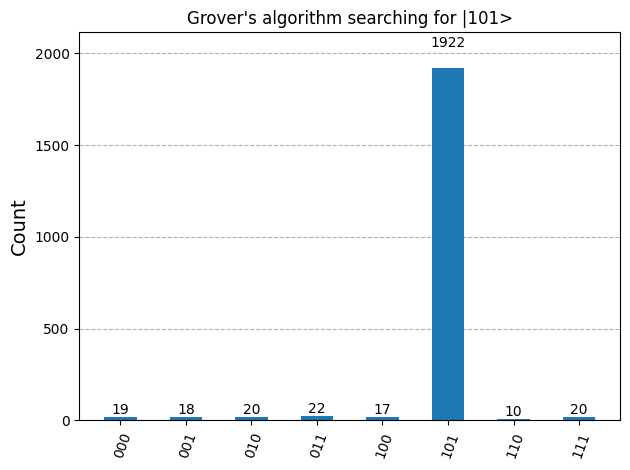

In [5]:
counts = simulator.run(transpile(qc, simulator), shots=2048).result().get_counts()
print("Measurement counts:", counts)
plot_histogram(counts, title=f"Grover's algorithm searching for |{marked_state}>")

In [6]:
most_likely = max(counts, key=counts.get)
print("Most frequently measured state:", most_likely)
print("Correct match!" if most_likely == marked_state else "No match found — try more shots.")

Most frequently measured state: 101
Correct match!


## Summary

The marked state `101` should appear far more often than any other
state — even though we only searched `~2` times instead of checking
all 8 items one by one.